### Step 1: Importing Necessary Libraries
We begin by importing Python libraries commonly used in data analysis and visualization:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting graphs
- `pandas` (commented out here) for handling CSV data, which is especially useful for tabular data such as redshift catalogs

> Tip: If you haven’t used `pandas` before, it’s worth learning as it offers powerful tools to manipulate and analyze structured datasets.


For reading big csv files, one can use numpy as well as something called "pandas". We suggest to read pandas for CSV file reading and use that

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c, M_sun
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


Before we begin calculations, we define key physical constants used throughout:

- $ H_0 $: Hubble constant, describes the expansion rate of the Universe.
- $c$ : Speed of light.
-  $G$: Gravitational constant.
- $q_0$ : Deceleration parameter, used for approximate co-moving distance calculations.

We will use **`astropy.constants`** to ensure unit consistency and precision.

In [3]:
# Constants:

H_0 = 2.27e-18 * u.s**-1 # Hubble constant in SI
c = c.to('m/s')   # Speed of light in m/s
G = G.to(u.pc * u.kg**-1 * (u.m / u.s)**2)  # Gravitational constant in pc kg^-1 (m/s)^2
q0=-0.534  # Deceleration parameter (assumed from Planck fit KEEP it as it is)
# print(c.to('km/s'))

Read the csv data into the python using the method below

In [4]:
df = pd.read_csv('Skyserver_SQL6_26_2025 10_58_29 AM.csv', comment='#') # Download the data as instructed in the pdf

### 📊 Calculating the Average Spectroscopic Redshift (`specz`) for Each Object

When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

```python
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()


In [5]:
print(df.columns)

Index(['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr',
       'proj_sep', 'umag', 'umagerr', 'gmag', 'gmagerr', 'rmag', 'rmagerr',
       'obj_type'],
      dtype='object')


In [6]:
# Calculating the average specz for each id:
averaged_df = df.groupby('objid').agg({'specz': 'mean','ra': 'first','dec': 'first','proj_sep': 'first',}).reset_index()
averaged_df.describe()['specz']

count    92.000000
mean      0.080838
std       0.008578
min       0.069976
25%       0.077224
50%       0.080961
75%       0.082797
max       0.150886
Name: specz, dtype: float64

To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group. 

Find the mean, standard deviation and limits of the redshift from the data

In [7]:
df['specz'] = pd.to_numeric(df['specz'], errors='coerce')  # Convert to numeric, ignore bad data
df = df.dropna(subset=['specz'])  # Drop rows with missing redshift
mean_z = df['specz'].mean() # mean of redshift
std_z = df['specz'].std() # standard deviation of redshift
min_z = df['specz'].min()
max_z = df['specz'].max()
print(f"Mean redshift       = {mean_z:.5f}")
print(f"Standard deviation  = {std_z:.5f}")
print(f"Minimum redshift    = {min_z:.5f}")
print(f"Maximum redshift    = {max_z:.5f}")

Mean redshift       = 0.08105
Standard deviation  = 0.00950
Minimum redshift    = 0.06997
Maximum redshift    = 0.15091


You can also use boxplot to visualize the overall values of redshift 

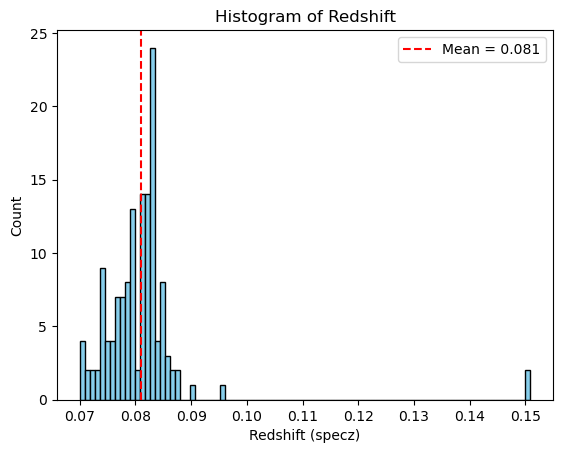

In [8]:
# Plot the dsitribution of redshift as histogram and a boxplot 
# plt.title("distribution of redshift for this data")
# Histogram
plt.hist(df['specz'], bins=90, color='skyblue', edgecolor='black')
plt.title('Histogram of Redshift')
plt.xlabel('Redshift (specz)')
plt.ylabel('Count')
plt.axvline(mean_z, color='red', linestyle='--', label=f'Mean = {mean_z:.3f}')
plt.legend()
plt.show()

But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

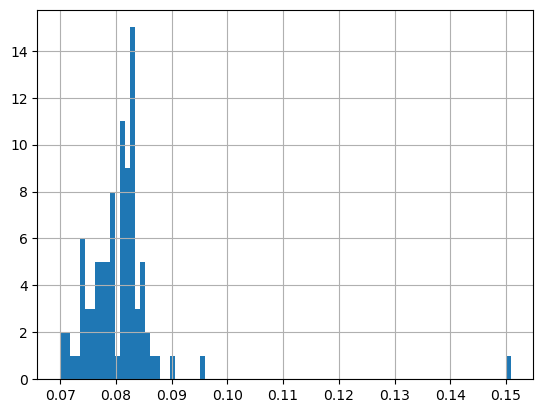

In [9]:
plt.hist(averaged_df['specz'],bins=90)
plt.grid()
plt.show()

Filter your data based on the 3-sigma limit of redshift. You should remove all data points which are 3-sigma away from mean of redshift

In [10]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.
filtered_df = df[(df['specz'] >= mean_z - 3*std_z) & (df['specz'] <= mean_z + 3*std_z)]

Use the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift 

In [11]:
df['velocity'] = (c * df['specz'].values * u.dimensionless_unscaled).to(u.km/u.s).value  # in km/s
print(df[['specz', 'velocity']].head())

      specz      velocity
0  0.082447  24717.081720
1  0.082466  24722.783773
2  0.081218  24348.666769
3  0.079561  23851.808736
4  0.079568  23853.802356


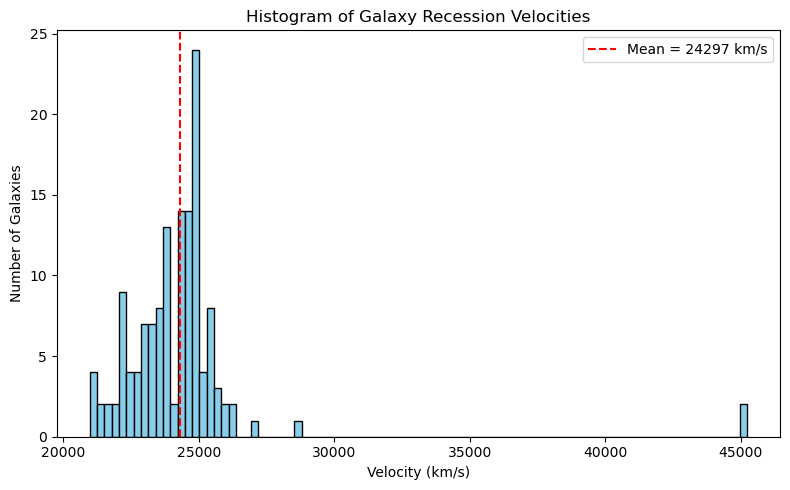

In [12]:
#plot the velocity column created as hist
plt.figure(figsize=(8, 5))
plt.hist(df['velocity'], bins=90, color='skyblue', edgecolor='black')
plt.title('Histogram of Galaxy Recession Velocities')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Number of Galaxies')
mean_v = df['velocity'].mean()
plt.axvline(mean_v, color='red', linestyle='--', label=f'Mean = {mean_v:.0f} km/s')
plt.legend()
plt.tight_layout()
plt.show()

use the dispersion equation to find something called velocity dispersion. You can even refer to wikipedia to know about the term [wiki link here](https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.)

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

### Step 2: Calculate Mean Redshift of the Cluster
We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [13]:
cluster_redshift = filtered_df['specz'].mean()
z = filtered_df['specz'].values * u.dimensionless_unscaled

Pro tip: Check what the describe function of pandas does. Does it help to get quick look stats for your column of dispersion??

In [14]:
filtered_df = filtered_df.copy()
v_rel = c*((1+z)**2-(1+cluster_redshift)**2)/((1+z)**2+(1+cluster_redshift)**2)
filtered_df['delta_v'] = v_rel.to(u.km/u.s).value
disp = filtered_df['delta_v'].std()

In [15]:
print(f"The value of the cluster redshift = {cluster_redshift:.4}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.4} km/s.")

The value of the cluster redshift = 0.08003
The characteristic value of velocity dispersion of the cluster along the line of sight = 1.203e+03 km/s.


In [16]:
z1 = cluster_redshift

### Step 4: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



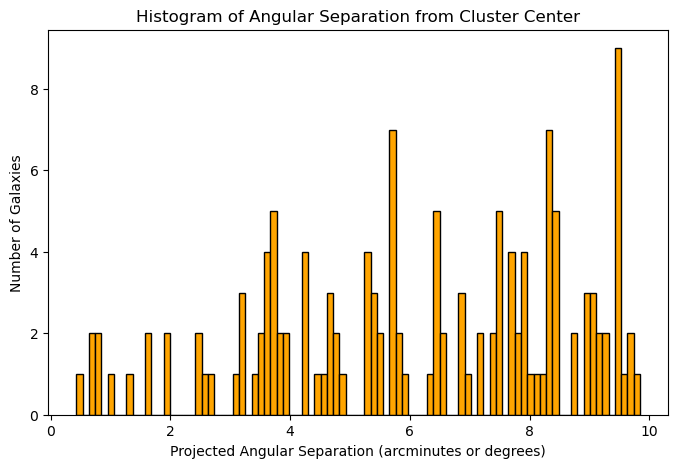

In [17]:
#Plot histogram for proj sep column
filtered_df['proj_sep'] = pd.to_numeric(filtered_df['proj_sep'], errors='coerce')
filtered_df = filtered_df.dropna(subset=['proj_sep'])
plt.figure(figsize=(8, 5))
plt.hist(filtered_df['proj_sep'], bins=90, color='orange', edgecolor='black')
plt.title('Histogram of Angular Separation from Cluster Center')
plt.xlabel('Projected Angular Separation (arcminutes or degrees)')
plt.ylabel('Number of Galaxies')
plt.show()

### Determining size and mass of the cluster:

### Step 5: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [18]:
theta_arcmin = filtered_df['proj_sep'].max()   # or median, or 95th percentile
theta_rad = (theta_arcmin * u.arcmin).to(u.rad).value

r= (c * z1 / H_0) * (1 - (z1 / 2) * (1 + q0))      # in meters
ra= r / (1 + z1)
diameter= (ra * theta_rad).to(u.Mpc)           # in megaparsecs
print(f"Estimated physical diameter of the cluster: {diameter:.3f}") #in Mpc

Estimated physical diameter of the cluster: 0.891 Mpc


### Step 6: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [19]:
### Calculating the dynamical mass in solar masses:
sigma = disp * u.km / u.s               # velocity dispersion
radius = 0.5 * diameter.to(u.m)         # cluster radius in meters
G_si = G.to(u.m**3 / (u.kg * u.s**2))   # G in SI units
M_dyn =(3 * sigma**2 * radius / G_si).to(u.kg)
M_dyn_solar = (M_dyn / M_sun).value
print(f"Dynamical Mass of the cluster is {M_dyn_solar:.2e} solar mass")

Dynamical Mass of the cluster is 4.50e+14 solar mass


In [22]:
### calculating total luminous mass
df = df[(df['photoz'] > 0) & (df['rmag'] > 0)]
lum_dist = cosmo.luminosity_distance(df['photoz']).to(u.pc).value
df['abs_rmag'] = df['rmag'] - 5 * np.log10(lum_dist / 10)
M_sun_r = 4.67
df['luminosity_Lsun'] = 10 ** ((M_sun_r - df['abs_rmag']) / 2.5)
mass_to_light_ratio = 3
df['stellar_mass_Msun'] = df['luminosity_Lsun'] * mass_to_light_ratio
total_luminous_mass = df['stellar_mass_Msun'].sum()
print(f"Total luminous mass of the cluster: {total_luminous_mass:.2e} solar masses")

Total luminous mass of the cluster: 1.31e+13 solar masses


In [23]:
print(M_dyn_solar/total_luminous_mass)

34.2038672523905
